In [4]:
import matplotlib.pyplot as plt
import numpy as np

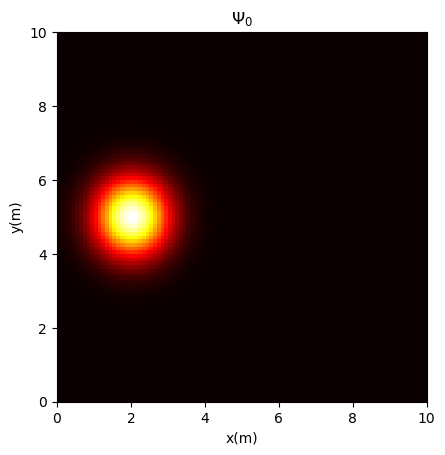

In [159]:
#1
L=10
x0=L/5
y0=L/2
sigma=0.75
kappa=15*np.pi
N=100
a=L/(N-1)
x=np.linspace(0,L,N)
y=np.linspace(0,L,N)
X,Y=np.meshgrid(x,y)
psi0=np.exp(-(X-x0)**2-(Y-y0)**2/(2*sigma**2))*np.exp(1j*kappa*(X-x0))
plt.imshow(abs(psi0),extent=[0,L,0,L],cmap='hot',origin='lower')
plt.title('$\Psi_0$')
plt.xlabel('x(m)')
plt.ylabel('y(m)')
plt.show()

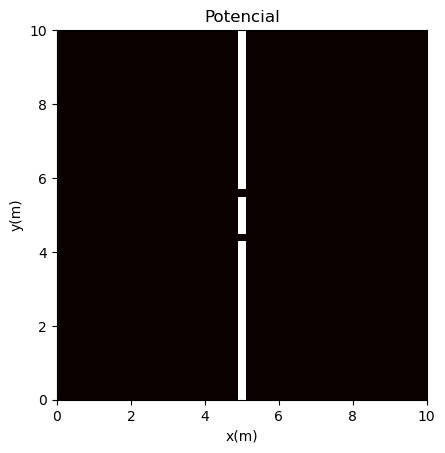

In [161]:
#2
x1=L/2-0.1
x2=L/2+0.1
y1=L/2-0.75
y2=L/2-0.5
y3=L/2+0.5
y4=L/2+0.75
def V(x,y):
    if (x1<=x<=x2) & ((0<=y<=y1) or (y2<=y<=y3) or(y4<=y<=L)):
        V=200
    else:
        V=0
    return V
V=np.vectorize(V)
V=V(X,Y)
plt.imshow(V,extent=(0, L, 0, L), origin="lower", cmap="hot")
plt.title('Potencial')
plt.xlabel('x(m)')
plt.ylabel('y(m)')
plt.show()

In [163]:
#3
ht=2*a**2
A=np.zeros([(N-2)**2,(N-2)**2],complex)
B=np.zeros([(N-2)**2,(N-2)**2],complex)
r=1j*ht/(2*a**2)
#Construcción de las matrices
for k in range(len(A)):
    i=k%(N-2)+1
    j=k//(N-2)+1
    
    A[k, k] = 1+4*r + 1j *ht/2*V[j, i]
    B[k, k] = 1-4*r - 1j*ht/2*V[j, i]
    if i>1:
        A[k,k-1]=-r
        B[k,k-1]=r
    if i<(N-2):
        A[k,k+1]=-r
        B[k,k+1]=r
    if j>1:
        A[k,k-(N-2)]=-r
        B[k,k-(N-2)]=r
    if j<(N-2):
        A[k,k+(N-2)]=-r
        B[k,k+(N-2)]=r
        

In [165]:
#4
from scipy.sparse import csc_matrix
from scipy.sparse.linalg import spsolve
psi=np.copy(psi0[1:N-1, 1:N-1])
Asp= csc_matrix(A)
sol=spsolve(Asp,B)
v=np.dot(B,psi.reshape((N-2)**2))
psi=spsolve(Asp,v).reshape(N-2,N-2)

In [167]:
#5
dpsi=np.zeros([N+1,N,N],complex)
dpsi[0, :, :] = psi0
for i in range(1,N+1):
        vectorv=np.dot(B, psi.reshape((N-2)**2))
        psi=spsolve(Asp, vectorv).reshape(N-2, N-2)
        dpsi[i, 1:-1, 1:-1] = psi
np.save("dpsi.npy", dpsi)

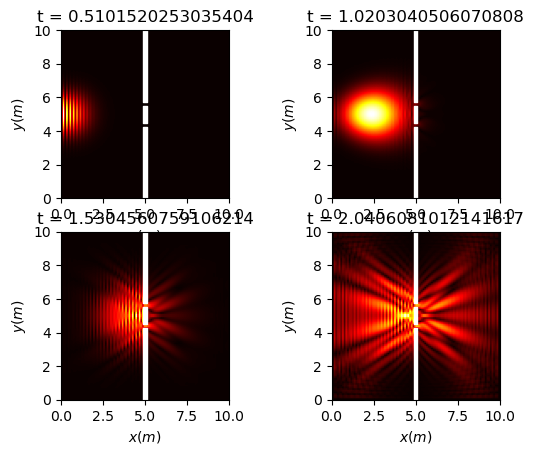

In [171]:
#6 
tp=np.array([25, 50, 75, 100])## esto no es lo mismo que tp=[25,50,75,100] por alguna razon
fig=plt.figure()
dpsi=np.load("dpsi.npy")
for i in range (len(tp)):
        ax = fig.add_subplot(2, 2, i+1)
        ax.set_title(f"t = {tp[i] * ht}")
        ax.set_xlabel(f"$x(m)$")
        ax.set_ylabel(f"$y(m)$")
        ax.fill_between([x1, x2], [0, 0], [y1, y1], color="w")
        ax.fill_between([x1, x2], [y2, y2], [y3, y3], color="w")
        ax.fill_between([x1, x2], [y4, y4], [L,L], color="w")
        ax.imshow(abs(dpsi[tp[i], :, :]), extent=(0, L, 0, L), origin="lower", cmap="hot")

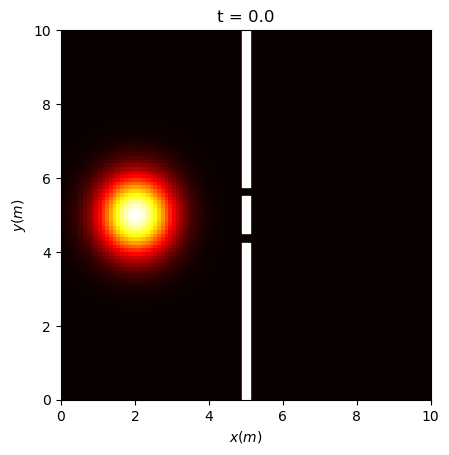

In [173]:
#7
from  matplotlib.animation import FuncAnimation
from IPython.core.display import HTML
fig=plt.figure()
ax=fig.add_subplot()
ax.set_title(f"t = {tp[0]}")
ax.set_xlabel(f"$x(m)$")
ax.set_ylabel(f"$y(m)$")
ax.fill_between([x1, x2], [0, 0], [y1, y1], color="w")
ax.fill_between([x1, x2], [y2, y2], [y3, y3], color="w")
ax.fill_between([x1, x2], [y4, y4], [L,L], color="w")
im = ax.imshow(abs(psi0), extent=(0,L, 0,L), origin="lower", cmap="hot")
ax.set_title(f"t = {0}")
def animacion(frame):
        im.set_data(abs(dpsi[frame]))
        ax.set_title(f"t = {frame*ht}")
ani =FuncAnimation(fig, animacion, frames=dpsi.shape[0], interval=20)
HTML(ani.to_jshtml())